In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Reload
df = pd.read_csv(r'C:\Users\JUNIAD KHAN\Desktop\credit_rank_score\data\accepted_2007_to_2018Q4.csv.gz', nrows=200000, low_memory=False)

# Strip whitespace from loan_status
df['loan_status'] = df['loan_status'].str.strip()

# Check all values
print(df['loan_status'].value_counts())

loan_status
Fully Paid            140992
Charged Off            35090
Current                22637
Late (31-120 days)       785
In Grace Period          347
Late (16-30 days)        148
Default                    1
Name: count, dtype: int64


In [2]:
# Keep only conclusive loans
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])]

# Create binary target
df['target'] = df['loan_status'].apply(lambda x: 0 if x == 'Fully Paid' else 1)

print(df['target'].value_counts())
print(f"\nDefault Rate: {df['target'].mean()*100:.2f}%")


target
0    140992
1     35091
Name: count, dtype: int64

Default Rate: 19.93%


In [3]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0].head(30))


sec_app_collections_12_mths_ex_med            100.000000
member_id                                     100.000000
revol_bal_joint                               100.000000
sec_app_fico_range_low                        100.000000
sec_app_fico_range_high                       100.000000
sec_app_earliest_cr_line                      100.000000
sec_app_inq_last_6mths                        100.000000
sec_app_mort_acc                              100.000000
sec_app_open_acc                              100.000000
sec_app_revol_util                            100.000000
sec_app_open_act_il                           100.000000
sec_app_num_rev_accts                         100.000000
sec_app_chargeoff_within_12_mths              100.000000
sec_app_mths_since_last_major_derog           100.000000
next_pymnt_d                                   99.999432
desc                                           99.994321
dti_joint                                      99.772834
annual_inc_joint               

In [4]:
th = 40 
col_to_drop = missing[missing > th].index
df = df.drop(columns = col_to_drop)


In [5]:
print(f"Columns dropped: {len(col_to_drop)}")
print(f"Remaining columns: {df.shape[1]}")


Columns dropped: 58
Remaining columns: 94


In [6]:
df.shape

(176083, 94)

In [7]:
df.dtypes.value_counts()

float64    69
object     23
int64       2
Name: count, dtype: int64

In [8]:
# Keep only relevant columns
cols_to_keep = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 
    'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 
    'verification_status', 'purpose', 'dti', 'delinq_2yrs',
    'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 
    'revol_util', 'total_acc', 'initial_list_status',
    'application_type', 'pub_rec_bankruptcies', 'target'
]

df = df[cols_to_keep]
print(df.shape)
print(df.head())

(176083, 23)
   loan_amnt        term  int_rate  installment grade sub_grade emp_length  \
0     3600.0   36 months     13.99       123.03     C        C4  10+ years   
1    24700.0   36 months     11.99       820.28     C        C1  10+ years   
2    20000.0   60 months     10.78       432.66     B        B4  10+ years   
4    10400.0   60 months     22.45       289.91     F        F1    3 years   
5    11950.0   36 months     13.44       405.18     C        C3    4 years   

  home_ownership  annual_inc verification_status  ... inq_last_6mths  \
0       MORTGAGE     55000.0        Not Verified  ...            1.0   
1       MORTGAGE     65000.0        Not Verified  ...            4.0   
2       MORTGAGE     63000.0        Not Verified  ...            0.0   
4       MORTGAGE    104433.0     Source Verified  ...            3.0   
5           RENT     34000.0     Source Verified  ...            0.0   

   open_acc  pub_rec  revol_bal  revol_util  total_acc  initial_list_status  \
0     

In [9]:
df.isnull().sum()

loan_amnt                   0
term                        0
int_rate                    0
installment                 0
grade                       0
sub_grade                   0
emp_length              11134
home_ownership              0
annual_inc                  0
verification_status         0
purpose                     0
dti                         2
delinq_2yrs                 0
inq_last_6mths              0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                 69
total_acc                   0
initial_list_status         0
application_type            0
pub_rec_bankruptcies        0
target                      0
dtype: int64

In [10]:
df['emp_lenght'].dtype

KeyError: 'emp_lenght'

In [11]:
df['emp_length'].dtype


dtype('O')

In [12]:
#df(df['emp_lenght'].fillna('Unknown', inplace= True ))
#df(df['dti'].fillna(df[dti].mean , inplace = True))   
#df(df['revol_util'].fillna(df[revol_util].mean , inplace = True))   

#print(df.isnull().sum().sum())   

df['emp_length'].fillna('Unknown', inplace=True)
df['revol_util'].fillna(df['revol_util'].median(), inplace=True)
df['dti'].fillna(df['dti'].median(), inplace=True)

print(df.isnull().sum())
print(df.isnull().sum().sum())

loan_amnt               0
term                    0
int_rate                0
installment             0
grade                   0
sub_grade               0
emp_length              0
home_ownership          0
annual_inc              0
verification_status     0
purpose                 0
dti                     0
delinq_2yrs             0
inq_last_6mths          0
open_acc                0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
initial_list_status     0
application_type        0
pub_rec_bankruptcies    0
target                  0
dtype: int64
0


In [13]:
print(df.dtypes)


loan_amnt               float64
term                     object
int_rate                float64
installment             float64
grade                    object
sub_grade                object
emp_length               object
home_ownership           object
annual_inc              float64
verification_status      object
purpose                  object
dti                     float64
delinq_2yrs             float64
inq_last_6mths          float64
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
initial_list_status      object
application_type         object
pub_rec_bankruptcies    float64
target                    int64
dtype: object


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/default_rate_by_grade.png'

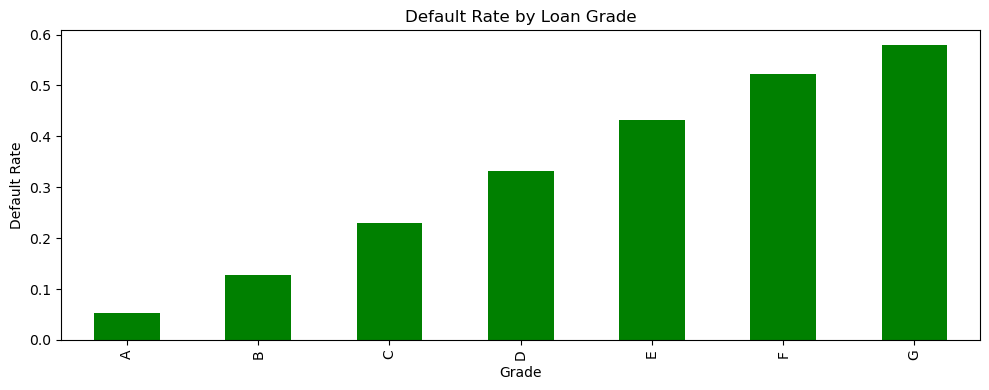

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Default rate by grade
plt.figure(figsize=(10,4))
df.groupby('grade')['target'].mean().sort_index().plot(kind='bar', color='green')
plt.title('Default Rate by Loan Grade')
plt.xlabel('Grade')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.savefig('../outputs/default_rate_by_grade.png')
plt.show()


In [17]:
df['target'].head(50)

0     0
1     0
2     0
4     0
5     0
6     0
7     0
8     0
9     0
12    0
13    1
14    0
15    0
16    0
17    0
19    0
20    0
21    0
22    0
23    0
24    0
25    1
26    0
27    0
28    0
29    0
30    1
31    1
32    0
33    1
35    0
36    0
37    0
38    0
39    0
40    0
41    1
43    0
44    0
45    0
46    0
47    0
49    0
50    0
54    0
56    0
57    0
58    0
59    0
60    1
Name: target, dtype: int64

In [18]:
df['grade'].head(50)

0     C
1     C
2     B
4     F
5     C
6     B
7     B
8     A
9     B
12    C
13    E
14    A
15    A
16    A
17    C
19    E
20    C
21    C
22    C
23    C
24    A
25    C
26    A
27    D
28    A
29    A
30    C
31    F
32    B
33    C
35    A
36    C
37    C
38    B
39    C
40    D
41    D
43    B
44    A
45    C
46    D
47    B
49    D
50    B
54    C
56    D
57    C
58    B
59    A
60    C
Name: grade, dtype: object

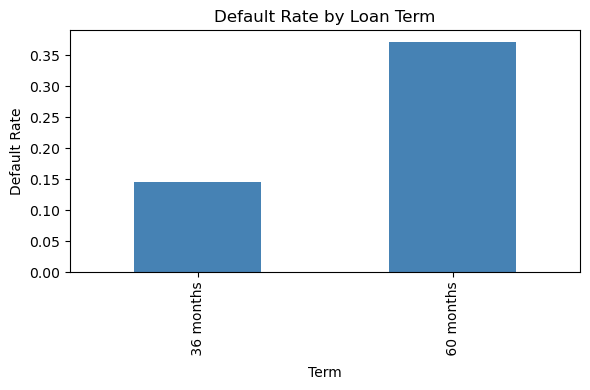

In [19]:
plt.figure(figsize=(6,4))
df.groupby('term')['target'].mean().plot(kind='bar', color='steelblue')
plt.title('Default Rate by Loan Term')
plt.xlabel('Term')
plt.ylabel('Default Rate')
plt.tight_layout()
#plt.savefig('../outputs/default_rate_by_term.png')
plt.show()


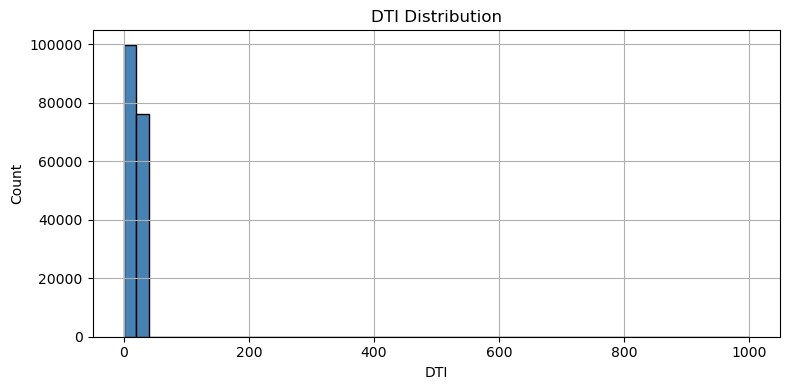

count    176083.000000
mean         18.911102
std           9.180762
min           0.000000
25%          12.310000
50%          18.340000
75%          25.090000
max         999.000000
Name: dti, dtype: float64


In [20]:
plt.figure(figsize=(8,4))
df['dti'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('DTI Distribution')
plt.xlabel('DTI')
plt.ylabel('Count')
plt.tight_layout()
#plt.savefig('../outputs/dti_distribution.png')
plt.show()

print(df['dti'].describe())

In [21]:
df = df[df['dti'] < 100]
print(df['dti'].describe())

count    176075.000000
mean         18.896971
std           8.682410
min           0.000000
25%          12.310000
50%          18.340000
75%          25.090000
max          90.000000
Name: dti, dtype: float64


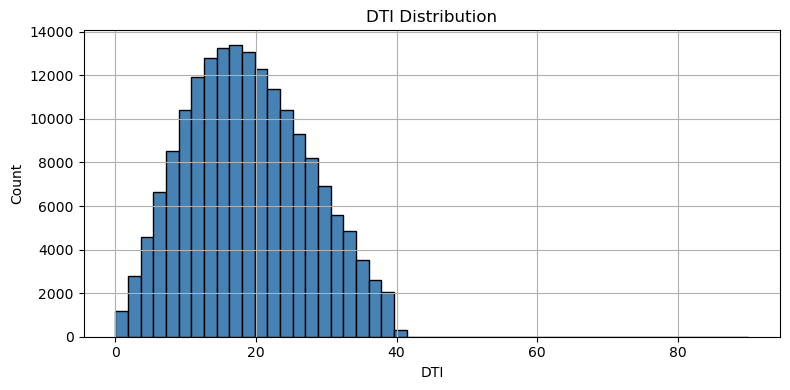

count    176075.000000
mean         18.896971
std           8.682410
min           0.000000
25%          12.310000
50%          18.340000
75%          25.090000
max          90.000000
Name: dti, dtype: float64


In [22]:
plt.figure(figsize=(8,4))
df['dti'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('DTI Distribution')
plt.xlabel('DTI')
plt.ylabel('Count')
plt.tight_layout()
#plt.savefig('../outputs/dti_distribution.png')
plt.show()

print(df['dti'].describe())


In [23]:
# Separate categorical and numerical columns
cat_cols = ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
            'verification_status', 'purpose', 'initial_list_status', 
            'application_type']

num_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
            'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
            'revol_bal', 'revol_util', 'total_acc', 'pub_rec_bankruptcies']

print(f"Categorical columns: {len(cat_cols)}")
print(f"Numerical columns: {len(num_cols)}")

Categorical columns: 9
Numerical columns: 13


In [24]:
df.dtypes


loan_amnt               float64
term                     object
int_rate                float64
installment             float64
grade                    object
sub_grade                object
emp_length               object
home_ownership           object
annual_inc              float64
verification_status      object
purpose                  object
dti                     float64
delinq_2yrs             float64
inq_last_6mths          float64
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
initial_list_status      object
application_type         object
pub_rec_bankruptcies    float64
target                    int64
dtype: object

In [25]:
def calculate_woe_iv(df, feature, target):
    df_temp = df[[feature, target]].copy()
    df_temp['Good'] = 1 - df_temp[target]
    df_temp['Bad'] = df_temp[target]
    
    grouped = df_temp.groupby(feature).agg(
        Good=('Good', 'sum'),
        Bad=('Bad', 'sum')
    ).reset_index()
    
    total_good = grouped['Good'].sum()
    total_bad = grouped['Bad'].sum()
    
    grouped['pct_good'] = grouped['Good'] / total_good
    grouped['pct_bad'] = grouped['Bad'] / total_bad
    grouped['WoE'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
    grouped['IV'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['WoE']
    grouped['IV_total'] = grouped['IV'].sum()
    
    return grouped

# Calculate IV for all categorical columns
iv_summary = {}
for col in cat_cols:
    result = calculate_woe_iv(df, col, 'target')
    iv_summary[col] = result['IV'].sum()

iv_df = pd.DataFrame.from_dict(iv_summary, orient='index', columns=['IV'])
iv_df = iv_df.sort_values('IV', ascending=False)
print(iv_df)


                           IV
home_ownership            inf
purpose                   inf
sub_grade            0.660986
grade                0.614704
term                 0.315484
verification_status  0.061817
emp_length           0.008062
initial_list_status  0.005308
application_type     0.000223


In [26]:
def calculate_woe_iv(df, feature, target):
    df_temp = df[[feature, target]].copy()
    df_temp['Good'] = 1 - df_temp[target]
    df_temp['Bad'] = df_temp[target]
    
    grouped = df_temp.groupby(feature).agg(
        Good=('Good', 'sum'),
        Bad=('Bad', 'sum')
    ).reset_index()
    
    total_good = grouped['Good'].sum()
    total_bad = grouped['Bad'].sum()
    
    grouped['pct_good'] = grouped['Good'] / total_good
    grouped['pct_bad'] = grouped['Bad'] / total_bad
    
    # Add small value to avoid log(0)
    grouped['WoE'] = np.log(
        (grouped['pct_good'] + 0.0001) / (grouped['pct_bad'] + 0.0001)
    )
    grouped['IV'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['WoE']
    
    return grouped

iv_summary = {}
for col in cat_cols:
    result = calculate_woe_iv(df, col, 'target')
    iv_summary[col] = result['IV'].sum()

iv_df = pd.DataFrame.from_dict(iv_summary, orient='index', columns=['IV'])
iv_df = iv_df.sort_values('IV', ascending=False)
print(iv_df)

                           IV
sub_grade            0.654567
grade                0.613590
term                 0.315390
verification_status  0.061794
home_ownership       0.027988
purpose              0.023380
emp_length           0.008052
initial_list_status  0.005307
application_type     0.000214


In [27]:
cols_to_keep = ['sub_garde','term','verification_status','home_ownership','purpose']
cols_to_drop = ['application_type','initial_list_status','emp_length','grade']
df = df.drop(columns = cols_to_drop)

In [28]:
print(df.shape)


(176075, 19)


In [29]:
def calculate_woe_iv_numeric(df, feature, target, bins=10):
    df_temp = df[[feature, target]].copy()
    df_temp['bin'] = pd.qcut(df_temp[feature], q=bins, duplicates='drop')
    df_temp['Good'] = 1 - df_temp[target]
    df_temp['Bad'] = df_temp[target]
    
    grouped = df_temp.groupby('bin').agg(
        Good=('Good', 'sum'),
        Bad=('Bad', 'sum')
    ).reset_index()
    
    total_good = grouped['Good'].sum()
    total_bad = grouped['Bad'].sum()
    
    grouped['pct_good'] = grouped['Good'] / total_good
    grouped['pct_bad'] = grouped['Bad'] / total_bad
    grouped['WoE'] = np.log(
        (grouped['pct_good'] + 0.0001) / (grouped['pct_bad'] + 0.0001)
    )
    grouped['IV'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['WoE']
    
    return grouped

iv_summary_num = {}
for col in num_cols:
    result = calculate_woe_iv_numeric(df, col, 'target')
    iv_summary_num[col] = result['IV'].sum()

iv_df_num = pd.DataFrame.from_dict(iv_summary_num, orient='index', columns=['IV'])
iv_df_num = iv_df_num.sort_values('IV', ascending=False)
print(iv_df_num)

                            IV
int_rate              0.642328
dti                   0.092781
loan_amnt             0.044623
installment           0.034860
inq_last_6mths        0.033256
annual_inc            0.030654
revol_util            0.020098
open_acc              0.011577
revol_bal             0.004559
total_acc             0.001915
delinq_2yrs           0.001570
pub_rec               0.001279
pub_rec_bankruptcies  0.000989


In [31]:
weak_num_cols = ['open_acc', 'revol_bal', 'total_acc', 
                 'delinq_2yrs', 'pub_rec', 'pub_rec_bankruptcies']
df = df.drop(columns = weak_num_cols )
num_cols = ['int_rate', 'dti', 'loan_amnt', 'installment', 
            'inq_last_6mths', 'annual_inc', 'revol_util']

print(df.shape
     )

(176075, 13)


In [33]:
cat_cols = ['term', 'sub_grade', 'home_ownership', 'verification_status', 'purpose']

In [34]:
# Store WoE mappings
woe_mappings = {}

# Categorical WoE transformation
for col in cat_cols:
    result = calculate_woe_iv(df, col, 'target')
    mapping = result.set_index(col)['WoE'].to_dict()
    woe_mappings[col] = mapping
    df[col + '_WoE'] = df[col].map(mapping)

# Numerical WoE transformation
for col in num_cols:
    df_temp = df[[col, 'target']].copy()
    df_temp['bin'] = pd.qcut(df_temp[col], q=10, duplicates='drop')
    result = calculate_woe_iv_numeric(df, col, 'target')
    mapping = result.set_index('bin')['WoE'].to_dict()
    woe_mappings[col] = mapping
    df[col + '_WoE'] = df_temp['bin'].map(mapping)

print(df.shape)
print(df[[c + '_WoE' for c in cat_cols + num_cols]].head())


(176075, 25)
   term_WoE  sub_grade_WoE  home_ownership_WoE  verification_status_WoE  \
0  0.374740      -0.352386            0.173640                 0.369059   
1  0.374740       0.038879            0.173640                 0.369059   
2 -0.863949       0.373453            0.173640                 0.369059   
4 -0.863949      -1.263768            0.173640                 0.034584   
5  0.374740      -0.229639           -0.181338                 0.034584   

   purpose_WoE int_rate_WoE   dti_WoE loan_amnt_WoE installment_WoE  \
0    -0.098302    -0.286514  0.450682      0.319351        0.435159   
1    -0.509070     0.222839  0.087793     -0.130842       -0.036504   
2     0.144330     0.444122  0.377973     -0.196800       -0.192100   
4     0.073012    -1.222700 -0.172422     -0.086003       -0.000754   
5    -0.098302    -0.286514  0.377973     -0.086003       -0.192100   

  inq_last_6mths_WoE annual_inc_WoE revol_util_WoE  
0           0.074576      -0.091669       0.203058  
1  

In [35]:
cat_cols = ['term', 'sub_grade', 'home_ownership', 'verification_status', 'purpose']

In [36]:
# Select only WoE columns for modeling
woe_cols = [c + '_WoE' for c in cat_cols + num_cols]
X = df[woe_cols]
y = df['target']

print(X.shape)
print(y.value_counts())

(176075, 12)
target
0    140984
1     35091
Name: count, dtype: int64


In [37]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42 ,stratify = y ) 


print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")


Train: (140860, 12)
Test: (35215, 12)


In [38]:
from sklearn.linear_model import LogisticRegression

In [40]:
model = LogisticRegression(max_iter = 1000)
model.fit(X_train,y_train)

print("Model trained successfully")
print(f"Coefficients: {model.coef_}")

Model trained successfully
Coefficients: [[-0.53774915 -0.7201757  -0.95057011 -0.27371638  0.08134382 -0.02075454
  -0.46225971  0.06804074 -0.5008475  -0.4113488  -0.46890544 -0.030261  ]]


In [41]:
from sklearn.metrics import roc_auc_score
import scipy.stats as stats

# Predict probabilities
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Gini
auc = roc_auc_score(y_test, y_pred_prob)
gini = 2 * auc - 1

# KS
good = y_pred_prob[y_test == 0]
bad = y_pred_prob[y_test == 1]
ks = stats.ks_2samp(good, bad).statistic

print(f"AUC: {auc:.4f}")
print(f"Gini: {gini:.4f}")
print(f"KS: {ks:.4f}")


AUC: 0.7362
Gini: 0.4723
KS: 0.3428


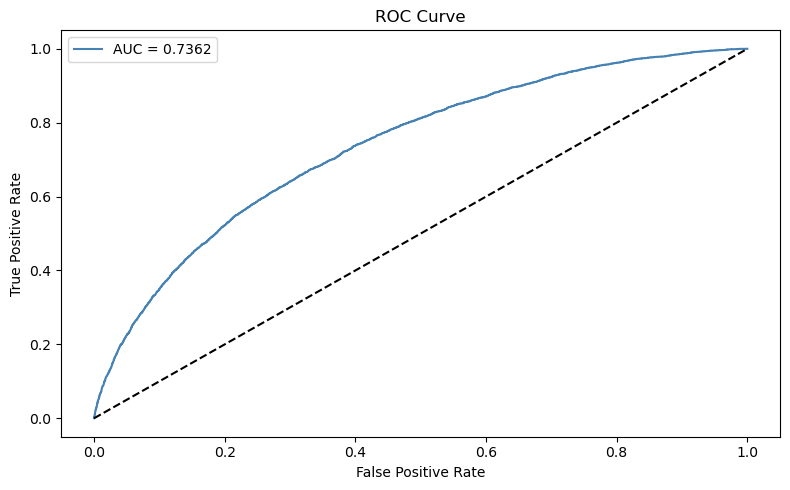

In [45]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, color='steelblue', label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
#plt.savefig('../outputs/roc_curve.png')
plt.show()

In [46]:
# Scorecard scaling
factor = 20 / np.log(2)
offset = 600 - factor * np.log(50)

# Calculate scores
X_test_scores = offset + factor * np.log(
    (1 - model.predict_proba(X_test)[:, 1]) / model.predict_proba(X_test)[:, 1]
)

# Add scores to test dataframe
test_results = X_test.copy()
test_results['score'] = X_test_scores
test_results['actual'] = y_test.values

print(test_results['score'].describe())

count    35215.000000
mean       534.506653
std         27.031030
min        456.765380
25%        516.189255
50%        534.708150
75%        553.352484
max        603.624002
Name: score, dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/score_distribution.png'

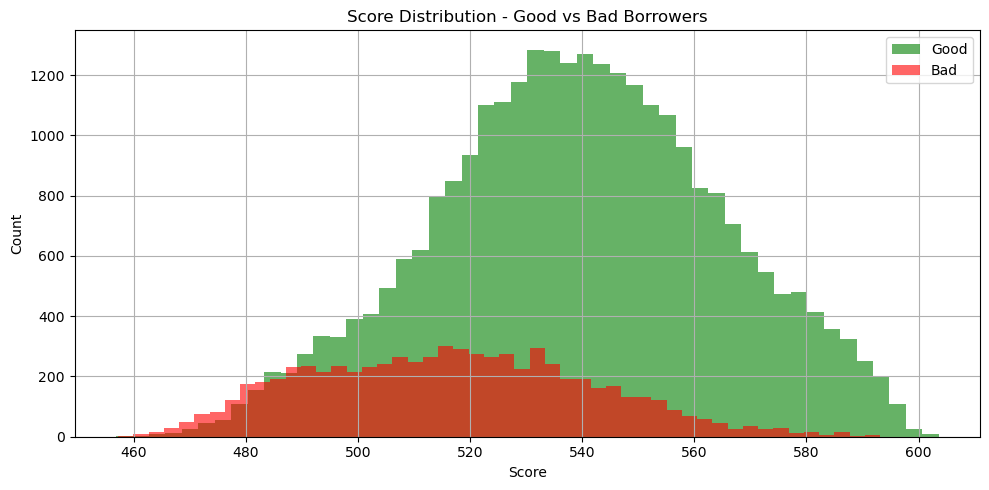

In [47]:
plt.figure(figsize=(10,5))
test_results[test_results['actual']==0]['score'].hist(
    bins=50, alpha=0.6, color='green', label='Good')
test_results[test_results['actual']==1]['score'].hist(
    bins=50, alpha=0.6, color='red', label='Bad')
plt.title('Score Distribution - Good vs Bad Borrowers')
plt.xlabel('Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/score_distribution.png')
plt.show()

In [52]:
import pickle

# Save model
with open(r'C:/Users/JUNIAD KHAN/Desktop/credit_rank_score/outputs/credit_scorecard_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save scorecard summary
scorecard_summary = pd.DataFrame({
    'Feature': woe_cols,
    'Coefficient': model.coef_[0]
})
scorecard_summary['Odds_Contribution'] = np.exp(scorecard_summary['Coefficient'])
scorecard_summary = scorecard_summary.sort_values('Coefficient')
scorecard_summary.to_csv('../outputs/scorecard_summary.csv', index=False)

print(scorecard_summary)

OSError: Cannot save file into a non-existent directory: '..\outputs'

In [53]:
scorecard_summary = pd.DataFrame({
    'Feature': woe_cols,
    'Coefficient': model.coef_[0]
})
scorecard_summary['Odds_Contribution'] = np.exp(scorecard_summary['Coefficient'])
scorecard_summary = scorecard_summary.sort_values('Coefficient')
scorecard_summary.to_csv(r'C:\Users\JUNIAD KHAN\Desktop\credit_rank_score\outputs\scorecard_summary.csv', index=False)
print(scorecard_summary)

                    Feature  Coefficient  Odds_Contribution
2        home_ownership_WoE    -0.950570           0.386521
1             sub_grade_WoE    -0.720176           0.486667
0                  term_WoE    -0.537749           0.584061
8           installment_WoE    -0.500847           0.606017
10           annual_inc_WoE    -0.468905           0.625687
6                   dti_WoE    -0.462260           0.629859
9        inq_last_6mths_WoE    -0.411349           0.662756
3   verification_status_WoE    -0.273716           0.760548
11           revol_util_WoE    -0.030261           0.970192
5              int_rate_WoE    -0.020755           0.979459
7             loan_amnt_WoE     0.068041           1.070409
4               purpose_WoE     0.081344           1.084744


In [56]:
import pandas as pd
import numpy as np

np.random.seed(20)
n = 100

sample = pd.DataFrame({
    'loan_amnt': np.random.randint(1000, 40000, n),
    'term': np.random.choice(['36 months', '60 months'], n),
    'int_rate': np.random.uniform(5, 30, n).round(2),
    'installment': np.random.uniform(50, 1500, n).round(2),
    'sub_grade': np.random.choice([f"{g}{n}" for g in 'ABCDEFG' for n in range(1,6)], n),
    'home_ownership': np.random.choice(['RENT', 'MORTGAGE', 'OWN'], n),
    'annual_inc': np.random.randint(20000, 200000, n),
    'verification_status': np.random.choice(['Not Verified', 'Verified', 'Source Verified'], n),
    'purpose': np.random.choice(['debt_consolidation', 'credit_card', 'home_improvement', 'other'], n),
    'dti': np.random.uniform(0, 40, n).round(2),
    'inq_last_6mths': np.random.randint(0, 10, n),
    'revol_util': np.random.uniform(0, 100, n).round(2)
})

sample.to_csv('sample_borrowers_1.csv', index=False)
print("Done")

Done


In [57]:
from IPython.display import FileLink
FileLink('sample_borrowers_1.csv')

C:\Users\JUNIAD KHAN\sample_borrowers_1.csv